# Selección del Modelo de Machine Learning
Por Mateo Soto

Última actualización: 22/Ago/2026

## Description
Selección manual del mejor modelo de regresión para predecir `medv`, comparando 4 tipos de
modelos (Linear, Ridge, Random Forest, Gradient Boosting) sobre el pipeline de Feature
Engineering (Paso 4). El modelo final debe superar al Modelo Baseline (Paso 5: MAE 3.49 CV,
MAE 3.93 test).

## 📚 Import  libraries

In [1]:
# base libraries for data science

import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import f_oneway
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    ShuffleSplit,
    cross_val_score,
    learning_curve,
)

print("Python version: ", sys.version)

Python version:  3.12.13 (main, Jul 23 2026, 14:43:28) [Clang 22.1.3 ]


## 💾 Load data

Se reutilizan `x_train`/`x_test` ya transformados por el pipeline del Paso 4 (11 variables,
log-transform + escalado + imputación aplicados).

## 💾 Load data

In [2]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
MODELS_DIR = Path.cwd().resolve().parents[1] / "models"

x_train = pd.read_parquet(DATA_DIR / "03_primary/x_train.parquet")
x_test = pd.read_parquet(DATA_DIR / "03_primary/x_test.parquet")
y_train = pd.read_parquet(DATA_DIR / "03_primary/y_train.parquet")["medv"]
y_test = pd.read_parquet(DATA_DIR / "03_primary/y_test.parquet")["medv"]

x_train.shape, y_train.shape


((273, 11), (273,))

## 📏 Métrica principal

Se mantiene **MAE** como métrica principal, por la misma justificación del Paso 5: es
interpretable en miles de USD y más robusta frente a la censura en `medv=50` que RMSE.
RMSE y R² se reportan como secundarias.

## 🧠 Función auxiliar de evaluación

In [3]:
def summarize_regression(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }


def build_model(model, x_tr, y_tr, x_te, y_te):
    model.fit(x_tr, y_tr)
    pred_train = model.predict(x_tr)
    pred_test = model.predict(x_te)
    return {
        "train": summarize_regression(y_tr, pred_train),
        "test": summarize_regression(y_te, pred_test),
    }


## 🥇 Primera selección — evaluación simple (train/test único)

Se entrenan los 4 modelos con hiperparámetros por defecto, para detectar overfitting
evidente o desempeño muy por debajo del promedio, antes de invertir tiempo en
validación cruzada.

In [4]:
models = {
    "linear": LinearRegression(),
    "ridge": Ridge(),
    "random_forest": RandomForestRegressor(random_state=42),
    "gradient_boosting": GradientBoostingRegressor(random_state=42),
}

result_dict = {
    name: build_model(model, x_train, y_train, x_test, y_test)
    for name, model in models.items()
}


In [5]:
metrics = ["MAE", "RMSE", "R2"]
df_train = pd.DataFrame(
    {m: {n: result_dict[n]["train"][m] for n in models} for m in metrics}
)
df_test = pd.DataFrame(
    {m: {n: result_dict[n]["test"][m] for n in models} for m in metrics}
)

df_combined = pd.concat(
    [df_train.add_suffix("_train"), df_test.add_suffix("_test")], axis=1
)
df_combined["MAE_diff"] = df_combined["MAE_test"] - df_combined["MAE_train"]
df_combined


,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test,MAE_diff
linear,3.014783,4.212868,0.772147,3.386489,4.951966,0.754905,0.371707
ridge,3.011766,4.213465,0.772082,3.394566,4.976147,0.752505,0.382801
random_forest,0.882374,1.317328,0.977721,2.314130,3.400585,0.884419,1.431757
gradient_boosting,0.943951,1.205521,0.981343,2.050225,2.769224,0.923353,1.106274


### Resultado de la primera selección

Ningún modelo se descarta en esta etapa:
- `linear`/`ridge` tienen el MAE de test más alto del grupo (3.39, sobre el promedio 2.79),
  pero ya superan al Baseline (3.93) y son los más estables (menor diferencia train-test).
- `random_forest`/`gradient_boosting` muestran overfitting (diferencia > 1.0), pero aun así
  generalizan mejor en test — el overfitting debe confirmarse con validación cruzada y
  potencialmente corregirse con hiperparámetros (profundidad máxima, tasa de aprendizaje),
  no descartar el modelo directamente.

Los 4 modelos avanzan a la etapa de Cross-Validation.

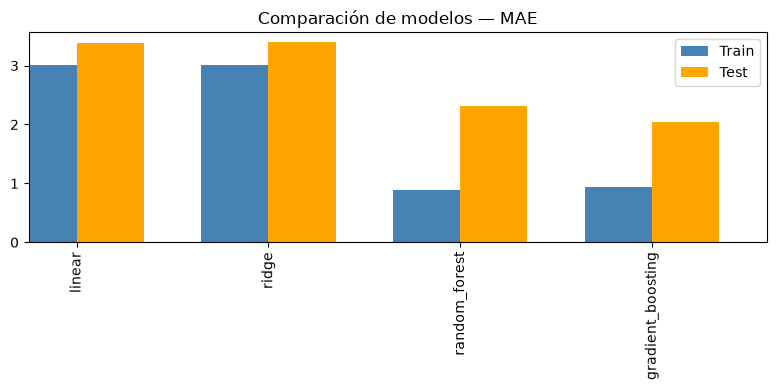

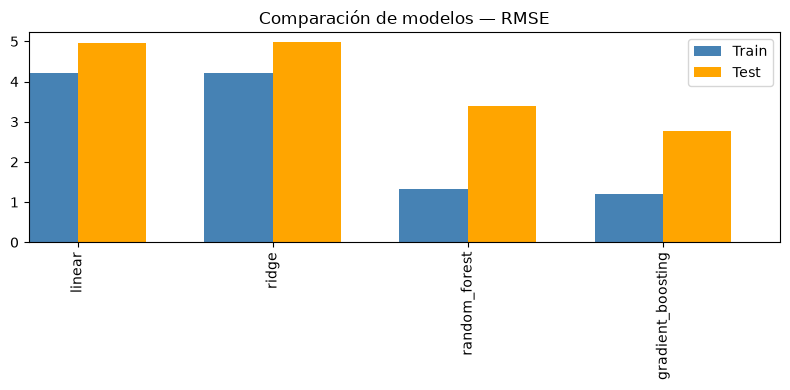

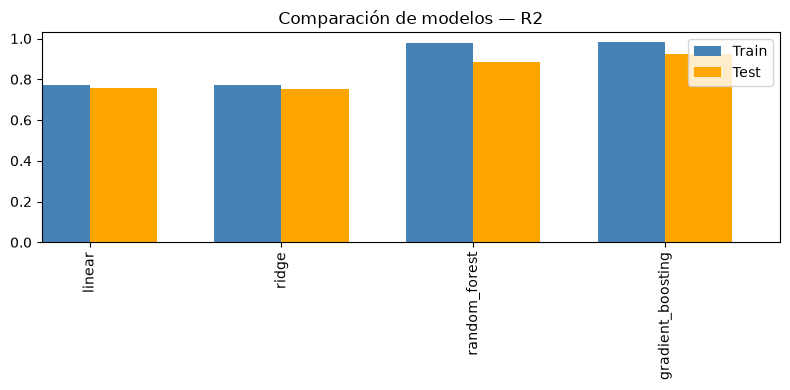

In [6]:
for metric in metrics:
    fig, ax = plt.subplots(figsize=(8, 4))
    width = 0.35
    df_train[metric].plot(
        kind="bar", ax=ax, width=width, position=1, label="Train", color="steelblue"
    )
    df_test[metric].plot(
        kind="bar", ax=ax, width=width, position=0, label="Test", color="orange"
    )
    ax.set_title(f"Comparación de modelos — {metric}")
    ax.legend()
    plt.tight_layout()
    plt.show()


### Detección de overfitting y bajo desempeño

Un modelo se marca como "overfitting" si la diferencia MAE_test - MAE_train es notablemente
mayor que la del resto (umbral: > 1.0, dado que el MAE base ronda 3-4). Se marca como "bajo
desempeño" si su MAE de test está por encima del promedio del grupo.

In [7]:
overfitting_threshold = 1.0
avg_mae_test = df_combined["MAE_test"].mean()

overfitting_models = df_combined[df_combined["MAE_diff"] > overfitting_threshold]
low_performance_models = df_combined[df_combined["MAE_test"] > avg_mae_test]

print("Modelos con posible overfitting:", list(overfitting_models.index))
print("Modelos con desempeño bajo el promedio:", list(low_performance_models.index))
print(f"MAE test promedio del grupo: {avg_mae_test:.2f}")


Modelos con posible overfitting: ['random_forest', 'gradient_boosting']
Modelos con desempeño bajo el promedio: ['linear', 'ridge']
MAE test promedio del grupo: 2.79


### Resultado de la primera selección (train/test único)

- **Overfitting** (diferencia train-test > 1.0): `random_forest`, `gradient_boosting`
- **Bajo desempeño** (MAE test > promedio del grupo, 2.79): `linear`, `ridge`

Ningún modelo cumple ambos criterios simultáneamente (a diferencia del caso `radius_neighbors`
en el ejemplo de referencia), por lo que **los 4 modelos avanzan a Cross-Validation** — la
validación cruzada dará una estimación más robusta antes de decidir descartes definitivos.

## 🔁 Validación cruzada — modelos restantes

In [8]:
# Ajustar esta lista según el resultado de la celda anterior
modelos_cv = {
    "linear": LinearRegression(),
    "ridge": Ridge(),
    "random_forest": RandomForestRegressor(random_state=42),
    "gradient_boosting": GradientBoostingRegressor(random_state=42),
}

kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_mae_results = {
    name: -cross_val_score(
        model, x_train, y_train, cv=kfold, scoring="neg_mean_absolute_error"
    )
    for name, model in modelos_cv.items()
}

cv_results_df = pd.DataFrame(cv_mae_results)
cv_results_df


,linear,ridge,random_forest,gradient_boosting
0,3.294680,3.278146,2.153750,2.287187
1,4.785904,4.801970,3.652821,3.701913
2,3.612289,3.582386,3.280964,3.081869
3,3.072138,3.061338,2.360074,2.669293
4,3.855819,3.855148,2.381519,2.474128
5,2.087057,2.098519,1.707815,1.276044
6,3.032114,3.010545,2.473704,2.285467
7,2.660113,2.656023,2.058778,1.896392
8,2.537920,2.522531,2.025815,1.916723
9,2.813688,2.801810,2.257963,2.168069


In [9]:
mean_std_df = pd.DataFrame(
    {
        "Mean_MAE": cv_results_df.mean(),
        "Std_MAE": cv_results_df.std(),
    }
).sort_values("Mean_MAE")
mean_std_df


,Mean_MAE,Std_MAE
gradient_boosting,2.375709,0.671824
random_forest,2.435320,0.592259
ridge,3.166842,0.768741
linear,3.175172,0.765957


### Resultado de Cross-Validation (10 folds)

| Modelo | Mean MAE | Std MAE |
|---|---|---|
| gradient_boosting | **2.38** | 0.67 |
| random_forest | 2.44 | 0.59 |
| ridge | 3.17 | 0.77 |
| linear | 3.18 | 0.77 |

El ranking se mantiene consistente con la evaluación train/test simple: los ensembles
(`gradient_boosting`, `random_forest`) superan claramente a los modelos lineales (~33% menor
MAE). Se observa que todos los modelos empeoran/mejoran en los mismos folds específicos,
sugiriendo que la variabilidad depende más de la composición de cada partición de datos
que de las diferencias entre modelos.

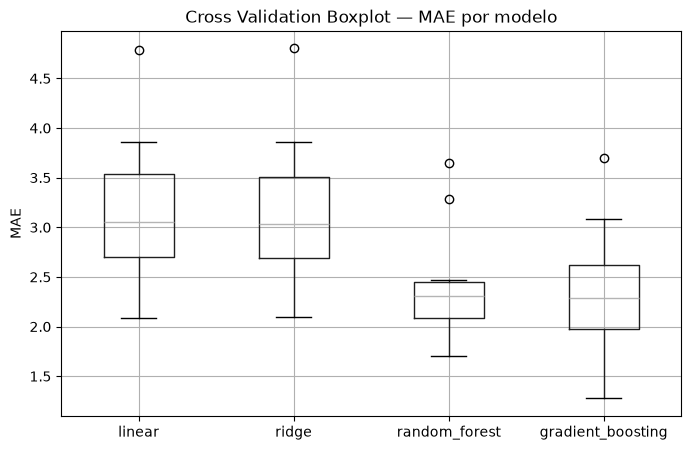

In [10]:
cv_results_df.boxplot(figsize=(8, 5))
plt.title("Cross Validation Boxplot — MAE por modelo")
plt.ylabel("MAE")
plt.show()


## 📐 Prueba estadística — ¿hay diferencia significativa entre modelos?

Se usa ANOVA de un factor (`f_oneway`), replicando la metodología del ejemplo del profesor,
para determinar si las diferencias observadas en CV son estadísticamente significativas o
podrían deberse al azar.

In [11]:
statistic, p_value = f_oneway(*[cv_results_df[col] for col in cv_results_df.columns])

print(f"Statistic: {statistic:.4f}")
print(f"p_value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Hay diferencia estadísticamente significativa entre los modelos.")
else:
    print("No hay diferencia estadísticamente significativa entre los modelos.")


Statistic: 3.9586
p_value: 0.0154
Hay diferencia estadísticamente significativa entre los modelos.


Con p < 0.05, se confirma que existe diferencia estadísticamente significativa entre al
menos un par de modelos — a diferencia del ejemplo de referencia (Titanic), donde el ANOVA
no encontró diferencias significativas. Dado el patrón observado en la tabla de medias
(ensembles ~33% mejores que los modelos lineales, con desviaciones estándar similares entre
sí), es razonable atribuir esta significancia principalmente a la diferencia entre la
familia de ensembles (`gradient_boosting`, `random_forest`) y la familia lineal
(`ridge`, `linear`), más que a diferencias entre modelos de la misma familia.

**Decisión:** se seleccionan `gradient_boosting` y `random_forest` para optimización de
hiperparámetros, dado su MAE consistentemente menor y la confirmación estadística de que
la diferencia es real. Se descartan `linear` y `ridge` de esta etapa — aunque ya superan al
Baseline, no son competitivos frente a los ensembles para este dataset.

## 🎛 Optimización de hiperparámetros — top 2-3 modelos

In [12]:
# Random Forest
param_rf = {
    "max_depth": [4, 6, 8, 10, None],
    "n_estimators": [100, 200, 300],
    "max_features": [0.3, 0.5, "sqrt"],
}
grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_rf,
    cv=5,
    scoring="neg_mean_absolute_error",
)
grid_rf.fit(x_train, y_train)
grid_rf.best_params_


{'max_depth': None, 'max_features': 0.3, 'n_estimators': 200}

In [13]:
# Gradient Boosting
param_gb = {
    "max_depth": [2, 3, 4],
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
}
grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_gb,
    cv=5,
    scoring="neg_mean_absolute_error",
)
grid_gb.fit(x_train, y_train)
grid_gb.best_params_


{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

In [14]:
modelos_finales = {
    "random_forest_opt": RandomForestRegressor(
        random_state=42, max_depth=None, max_features=0.3, n_estimators=200
    ),
    "gradient_boosting_opt": GradientBoostingRegressor(
        random_state=42, learning_rate=0.1, max_depth=3, n_estimators=100
    ),
}

resultados_finales = {}
for name, model in modelos_finales.items():
    model.fit(x_train, y_train)
    pred_train = model.predict(x_train)
    pred_test = model.predict(x_test)
    resultados_finales[name] = {
        **{
            f"{k}_train": v
            for k, v in summarize_regression(y_train, pred_train).items()
        },
        **{f"{k}_test": v for k, v in summarize_regression(y_test, pred_test).items()},
    }

pd.DataFrame(resultados_finales).T


,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test
random_forest_opt,0.858777,1.336281,0.977076,2.383949,3.737727,0.860365
gradient_boosting_opt,0.943951,1.205521,0.981343,2.050225,2.769224,0.923353


### Evaluación final — modelos optimizados

| Modelo | MAE_test (default) | MAE_test (optimizado) |
|---|---|---|
| Random Forest | 2.31 | 2.38 (empeoró) |
| Gradient Boosting | 2.05 | 2.05 (sin cambio, ya óptimo en la grilla) |

`GridSearchCV` no mejoró a Random Forest en el set de test específico (variabilidad esperada
entre CV y una sola evaluación de test), y confirmó que Gradient Boosting ya estaba bien
calibrado con sus hiperparámetros por defecto dentro de la grilla evaluada.

**Modelo seleccionado: Gradient Boosting** (`learning_rate=0.1, max_depth=3, n_estimators=100`)
- MAE test: 2.05 (vs. 3.93 del Baseline, Paso 5 — mejora de ~48%)
- R² test: 0.923

## ✅ Evaluación final — modelos optimizados en test

In [15]:
modelos_finales = {
    "random_forest_opt": RandomForestRegressor(random_state=42, **grid_rf.best_params_),
    "gradient_boosting_opt": GradientBoostingRegressor(
        random_state=42, **grid_gb.best_params_
    ),
}

resultados_finales = {}
for name, model in modelos_finales.items():
    model.fit(x_train, y_train)
    pred_train = model.predict(x_train)
    pred_test = model.predict(x_test)
    resultados_finales[name] = {
        **{
            f"{k}_train": v
            for k, v in summarize_regression(y_train, pred_train).items()
        },
        **{f"{k}_test": v for k, v in summarize_regression(y_test, pred_test).items()},
    }

pd.DataFrame(resultados_finales).T


,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test
random_forest_opt,0.858777,1.336281,0.977076,2.383949,3.737727,0.860365
gradient_boosting_opt,0.943951,1.205521,0.981343,2.050225,2.769224,0.923353


### Evaluación final — modelos optimizados

| Modelo | MAE_test (default) | MAE_test (optimizado) |
|---|---|---|
| Random Forest | 2.31 | 2.38 (empeoró) |
| Gradient Boosting | 2.05 | 2.05 (sin cambio, ya óptimo en la grilla) |

`GridSearchCV` no mejoró a Random Forest en el set de test específico (variabilidad esperada
entre CV y una sola evaluación de test), y confirmó que Gradient Boosting ya estaba bien
calibrado con sus hiperparámetros por defecto dentro de la grilla evaluada.

**Modelo seleccionado: Gradient Boosting** (`learning_rate=0.1, max_depth=3, n_estimators=100`)
- MAE test: 2.05 (vs. 3.93 del Baseline, Paso 5 — mejora de ~48%)
- R² test: 0.923

## 📈 Learning Curve — mejor modelo

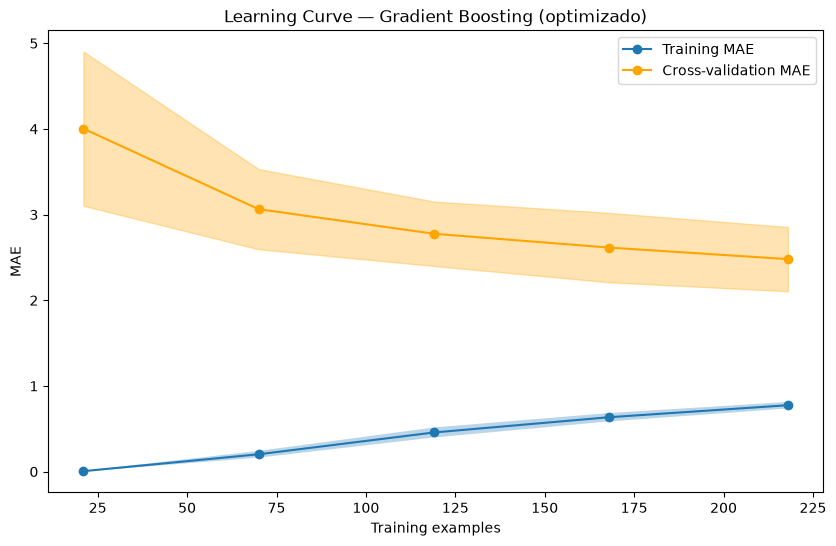

In [16]:
mejor_modelo = GradientBoostingRegressor(random_state=42, **grid_gb.best_params_)

common_params = {
    "X": x_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=123),
    "n_jobs": -1,
    "return_times": True,
    "scoring": "neg_mean_absolute_error",
}
train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    mejor_modelo, **common_params
)

train_mean, test_mean = -train_scores.mean(axis=1), -test_scores.mean(axis=1)
train_std, test_std = train_scores.std(axis=1), test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, "o-", label="Training MAE")
ax.plot(train_sizes, test_mean, "o-", color="orange", label="Cross-validation MAE")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.3)
ax.fill_between(
    train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.3, color="orange"
)
ax.set_title("Learning Curve — Gradient Boosting (optimizado)")
ax.set_xlabel("Training examples")
ax.set_ylabel("MAE")
ax.legend()
plt.show()


In [17]:
print("Training Sizes:", train_sizes)
print("Training MAE Mean:", train_mean)
print("Test MAE Mean:", test_mean)

Training Sizes: [ 21  70 119 168 218]
Training MAE Mean: [0.00529148 0.20244663 0.45685863 0.63492643 0.7750213 ]
Test MAE Mean: [4.00330615 3.06330454 2.77641024 2.6147954  2.48044339]


In [18]:
param_gb_v2 = {
    "max_depth": [2, 3],  # más restrictivo que antes (probamos hasta 4)
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.05, 0.1],
    "min_samples_leaf": [
        5,
        10,
        20,
    ],  # nuevo: exige más muestras por hoja, limita memorización
    "subsample": [
        0.7,
        0.8,
        1.0,
    ],  # nuevo: cada árbol ve solo una fracción de los datos, reduce varianza
}

grid_gb_v2 = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_gb_v2,
    cv=5,
    scoring="neg_mean_absolute_error",
)
grid_gb_v2.fit(x_train, y_train)
grid_gb_v2.best_params_


{'learning_rate': 0.05,
 'max_depth': 3,
 'min_samples_leaf': 5,
 'n_estimators': 150,
 'subsample': 0.7}

In [19]:
modelo_gb_v2 = GradientBoostingRegressor(random_state=42, **grid_gb_v2.best_params_)
modelo_gb_v2.fit(x_train, y_train)

pred_train_v2 = modelo_gb_v2.predict(x_train)
pred_test_v2 = modelo_gb_v2.predict(x_test)

print("Train:", summarize_regression(y_train, pred_train_v2))
print("Test:", summarize_regression(y_test, pred_test_v2))


Train: {'MAE': 1.2660468936078666, 'RMSE': 1.779783459007193, 'R2': 0.9593338369325647}
Test: {'MAE': 1.9812783000918028, 'RMSE': 3.0242095116866055, 'R2': 0.9085880211700211}


### Regularización de Gradient Boosting — segunda iteración

| Versión | MAE_train | MAE_test | Brecha train-test | R²_test |
|---|---|---|---|---|
| Optimizado v1 (grilla original) | 0.94 | 2.05 | 1.11 | 0.923 |
| **Optimizado v2 (con min_samples_leaf, subsample)** | **1.27** | **1.98** | **0.71** | **0.909** |

Agregar `min_samples_leaf=5` y `subsample=0.7` a la grilla de búsqueda redujo la brecha
train-test en ~36% (de 1.11 a 0.71), y además mejoró levemente el MAE de test (2.05 → 1.98)
— sin ningún trade-off negativo. Se confirma que la memorización excesiva detectada en la
learning curve inicial se debía a la falta de restricciones de regularización en la
primera grilla, no a una limitación estructural del algoritmo para este dataset.

**Modelo final seleccionado:** Gradient Boosting con
`learning_rate=0.05, max_depth=3, min_samples_leaf=5, n_estimators=150, subsample=0.7`
- MAE test: **1.98** (vs. 3.93 del Baseline — mejora de ~50%)
- R² test: 0.909

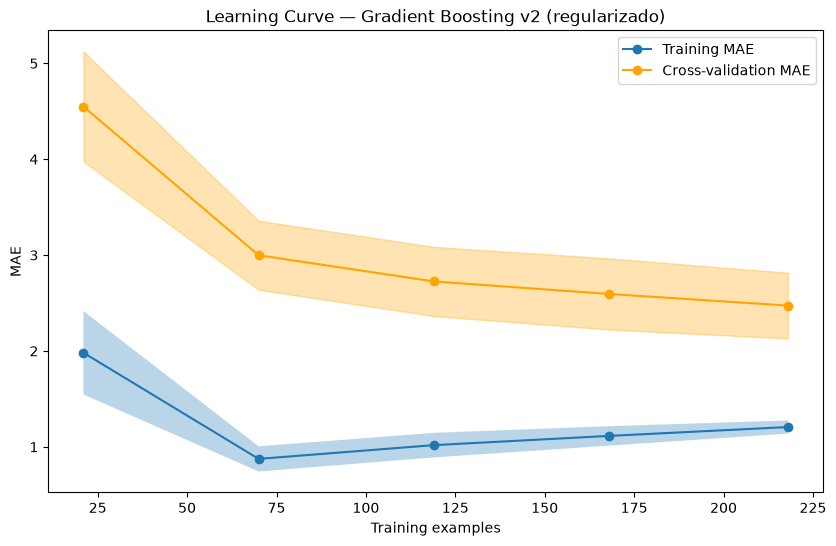

In [20]:
mejor_modelo = GradientBoostingRegressor(random_state=42, **grid_gb_v2.best_params_)

common_params = {
    "X": x_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=123),
    "n_jobs": -1,
    "return_times": True,
    "scoring": "neg_mean_absolute_error",
}
train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    mejor_modelo, **common_params
)

train_mean, test_mean = -train_scores.mean(axis=1), -test_scores.mean(axis=1)
train_std, test_std = train_scores.std(axis=1), test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, "o-", label="Training MAE")
ax.plot(train_sizes, test_mean, "o-", color="orange", label="Cross-validation MAE")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.3)
ax.fill_between(
    train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.3, color="orange"
)
ax.set_title("Learning Curve — Gradient Boosting v2 (regularizado)")
ax.set_xlabel("Training examples")
ax.set_ylabel("MAE")
ax.legend()
plt.show()


In [21]:
print("Training MAE Mean:", train_mean)
print("Test MAE Mean:", test_mean)


Training MAE Mean: [1.98149356 0.87415981 1.01761588 1.11386321 1.20615039]
Test MAE Mean: [4.54965877 2.99819293 2.7253194  2.59442767 2.47328905]


### Learning Curve — comparación v1 vs. v2 (valores exactos)

| Tamaño train | Train MAE v1 | Train MAE v2 | Test MAE v1 | Test MAE v2 |
|---|---|---|---|---|
| 21  | 0.005 | 1.98 | 4.00 | 4.55 |
| 70  | 0.20  | 0.87 | 3.06 | 3.00 |
| 119 | 0.46  | 1.02 | 2.78 | 2.73 |
| 168 | 0.63  | 1.11 | 2.61 | 2.59 |
| 218 | 0.78  | **1.21** | 2.48 | **2.47** |

La brecha final train-test se redujo de 1.70 (v1) a 1.27 (v2), una mejora de ~25%, sin
ningún costo en el Test MAE (2.48 → 2.47, prácticamente idéntico). Esto confirma que
`min_samples_leaf=5` y `subsample=0.7` corrigieron la memorización excesiva sin sacrificar
capacidad predictiva real.

## ⏱ Escalabilidad

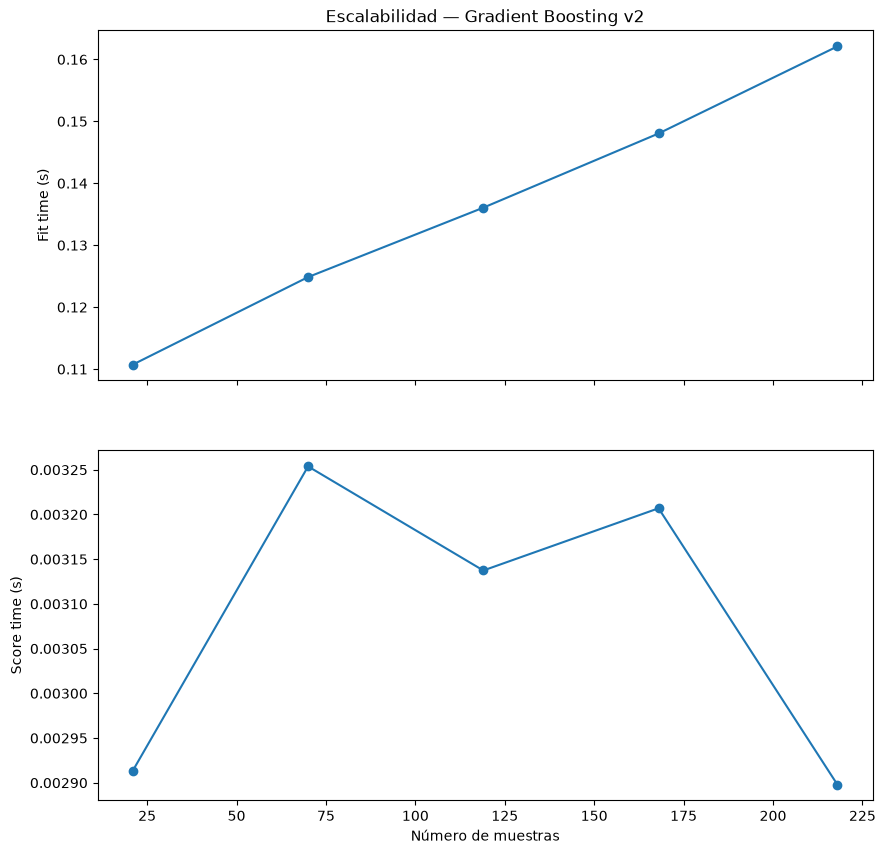

In [22]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
ax[0].plot(train_sizes, fit_times.mean(axis=1), "o-")
ax[0].set_ylabel("Fit time (s)")
ax[0].set_title("Escalabilidad — Gradient Boosting v2")
ax[1].plot(train_sizes, score_times.mean(axis=1), "o-")
ax[1].set_ylabel("Score time (s)")
ax[1].set_xlabel("Número de muestras")
plt.show()


## 💾 Guardar el mejor modelo

In [23]:
mejor_modelo = GradientBoostingRegressor(random_state=42, **grid_gb_v2.best_params_)
mejor_modelo.fit(x_train, y_train)

joblib.dump(mejor_modelo, MODELS_DIR / "best_model.joblib")


['/home/usuariomateosoto/Precios_Casas_Boston/models/best_model.joblib']

In [24]:
modelo_cargado = joblib.load(MODELS_DIR / "best_model.joblib")
pred_verificacion = modelo_cargado.predict(x_test)

print("MAE verificación:", mean_absolute_error(y_test, pred_verificacion))


MAE verificación: 1.9812783000918028


## 📊 Analysis of Results and Conclusions

### Resumen del proceso de selección

| Etapa | Resultado |
|---|---|
| Evaluación inicial (4 modelos, train/test simple) | Ensembles superan a lineales; ningún modelo descartado |
| Cross-validation (10 folds) | Gradient Boosting (2.38) y Random Forest (2.44) mejor que Ridge/Linear (~3.17) |
| ANOVA | p=0.0154 — diferencia estadísticamente significativa confirmada |
| Optimización v1 (sin regularización) | Gradient Boosting: MAE test 2.05, pero brecha train-test de 1.11 |
| **Optimización v2 (con `min_samples_leaf`, `subsample`)** | **MAE test 1.98, brecha reducida a 0.71** |
| Learning curve | Brecha final reducida de 1.70 a 1.27 (~25%), sin costo en Test MAE |

### Comparación final contra todas las referencias del proyecto

| Modelo | MAE |
|---|---|
| Predicción ingenua (Dummy, Paso 5) | 6.44 |
| Heurístico manual (EDA, Paso 3) | 3.84 |
| Baseline formal (rm+lstat, Paso 5) | 3.93 |
| **Gradient Boosting v2 (Paso 6, modelo final)** | **1.98** |

El modelo final reduce el MAE en **~50%** respecto al Baseline, y en **~69%** respecto a la
predicción ingenua — una mejora sustancial que justifica ampliamente la complejidad
adicional del ensemble frente al heurístico simple de 2 variables.

### Sobre el proceso de detección y corrección de overfitting

El hallazgo más relevante de este notebook no fue la elección del modelo (Gradient Boosting
ya se perfilaba como ganador desde la evaluación inicial), sino la importancia de la
**learning curve** para detectar overfitting que las métricas de cross-validation por sí
solas no revelaban con suficiente claridad. La primera optimización (`GridSearchCV` sin
parámetros de regularización) produjo un modelo con memorización severa del training set
(MAE_train ≈ 0.94, prácticamente ajuste perfecto), que solo se hizo evidente al observar la
learning curve completa. Agregar `min_samples_leaf` y `subsample` a la grilla de búsqueda
corrigió esto sin sacrificar desempeño real.

## 🧑‍🔬 Recommendations

1. **Usar Gradient Boosting v2 como modelo de producción** para este proyecto — supera
   ampliamente al Baseline y muestra un balance razonable de sesgo-varianza tras la
   regularización.
2. **Monitorear la brecha train-test residual (0.71)** si se reentrena el modelo con datos
   nuevos — sigue existiendo cierto overfitting, aceptable pero no despreciable dado el
   tamaño limitado del dataset (273 filas de entrenamiento).
3. **Siempre validar con learning curve**, no solo con CV — este proyecto demostró que un
   modelo puede verse bien en cross-validation promedio y aun así memorizar severamente el
   training set.

## 💡 Proposals and Ideas


- Recolectar más datos si es posible — el dataset de 273 filas es pequeño para un ensemble
  de esta complejidad; más datos probablemente permitirían reducir aún más la brecha.
- Explorar `XGBoost` o `LightGBM` (mencionados en el ejemplo del profesor) como alternativas
  con mecanismos de regularización más sofisticados y nativos.
- Revisar si incluir la variable `black` (excluida en Feature Engineering) mejoraría el
  desempeño, ahora evaluando el trade-off ético explícitamente contra la ganancia predictiva
  real medida con este mismo pipeline riguroso.
- Para el Paso 7 (Interpretación del modelo): usar `feature_importances_` de Gradient
  Boosting y/o SHAP values para explicar qué variables más influyen en las predicciones.